In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torch.nn.functional as F
from torch.autograd import Variable

import random
import os
import numpy as np
import pandas as pd
import math
import sys
from collections import Counter
from itertools import chain
from typing import List
import textwrap

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

from google.colab import drive

random.seed(0)
torch.manual_seed(0)

In [3]:
drive.mount('/content/gdrive')

base_dir = "/content/gdrive/MyDrive/CS4782-Final/"
sys.path.append(base_dir)

Mounted at /content/gdrive


In [4]:
%load_ext autoreload
%aimport PatchTST
%aimport PatchTST_self_supervised
%aimport utils
%aimport data_loader
%autoreload 1


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(F"Device set to {device}")

Device set to cuda


In [5]:
from data_loader import TimeSeriesDataset, SelfSupervisedTimeSeriesDataset
from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset, DataLoader, Subset


input_length    = 336   # e.g. past 512 steps
forecast_horizon= 96    # e.g. next 96 steps
                        # The paper uses {96,192,336,720}
batch_size      = 32
patch_length    = 12

# dataset = TimeSeriesDataset(base_dir + "data/ETTh1.csv", input_length, forecast_horizon)
# n_total = len(dataset)
# n_train = int(0.8 * n_total)
# train_idx = list(range(0, n_train))
# val_idx   = list(range(n_train, n_total))

# train_ds = Subset(dataset, train_idx)
# val_ds   = Subset(dataset, val_idx)

# train_loader = DataLoader(
#     train_ds,
#     batch_size=batch_size,
#     shuffle=True,
#     drop_last=True
# )

# val_loader = DataLoader(
#     val_ds,
#     batch_size=batch_size,
#     shuffle=False
# )



df   = pd.read_csv(base_dir + "data/ETTm1.csv", parse_dates=["date"])
vars = ['HUFL','HULL','MUFL','MULL','LUFL','LULL','OT']
data = df[vars].values

# 2) Determine time‐based split point
n_train_time = int(0.8 * len(data))

# 3) Slice train & val (include overlap of input_length for first val window)
train_raw = data[:n_train_time]
val_raw   = data[n_train_time - input_length :]

# 4) Fit scaler on TRAIN ONLY, then transform both
scaler     = StandardScaler().fit(train_raw)
train_data = scaler.transform(train_raw)
val_data   = scaler.transform(val_raw)

# 5) Array‐based dataset
class ArrayTimeSeriesDataset(Dataset):
    def __init__(self, data: np.ndarray, input_length: int, horizon: int):
        """
        data: 2D array [T, n_vars] already scaled
        """
        self.data = data
        self.L, self.h = input_length, horizon
        self.n_samples = len(data) - input_length - horizon + 1

    def __len__(self):
        return self.n_samples

    def __getitem__(self, idx):
        x = self.data[idx : idx + self.L]                       # [L, n_vars]
        y = self.data[idx + self.L : idx + self.L + self.h]     # [h, n_vars]
        # transpose to [n_vars, seq_len]
        return (
            torch.from_numpy(x.T).float(),
            torch.from_numpy(y.T).float()
        )

# 6) Build datasets & loaders
train_ds = ArrayTimeSeriesDataset(train_data, input_length, forecast_horizon)
val_ds   = ArrayTimeSeriesDataset(val_data,   input_length, forecast_horizon)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  drop_last=True)
val_loader   = DataLoader(val_ds, batch_size=32, shuffle=False, drop_last=False)


In [8]:
from PatchTST import PatchTST
from utils import train, val

criterion = nn.MSELoss()
model = PatchTST(input_length=input_length, patch_len=patch_length,
                     stride=8, forecast_horizon=forecast_horizon, d_model=128, n_heads=16).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3, betas=(0.9, 0.98), eps=1e-9)
print('here')
train_loss_arr, _, val_loss_arr, _ = train(
    model, train_loader, val_loader,
    criterion, epochs=4,
    optimizer=optimizer, device=device
)

here
Starting training...
Epoch 1/4


train: 100%|██████████| 1728/1728 [01:36<00:00, 17.85it/s]


Epoch 1: Train Loss = 0.2851, Train MAE = 0.3651 | Val   Loss = 0.3289, Val   MAE = 0.3825
Epoch 2/4


train: 100%|██████████| 1728/1728 [01:36<00:00, 17.97it/s]


Epoch 2: Train Loss = 0.2494, Train MAE = 0.3415 | Val   Loss = 0.3373, Val   MAE = 0.3844
Epoch 3/4


train: 100%|██████████| 1728/1728 [01:35<00:00, 18.07it/s]


Epoch 3: Train Loss = 0.2390, Train MAE = 0.3343 | Val   Loss = 0.3421, Val   MAE = 0.3815
Epoch 4/4


train: 100%|██████████| 1728/1728 [01:36<00:00, 17.99it/s]


Epoch 4: Train Loss = 0.2309, Train MAE = 0.3288 | Val   Loss = 0.3378, Val   MAE = 0.3846
Training finished.


ValueError: too many values to unpack (expected 2)

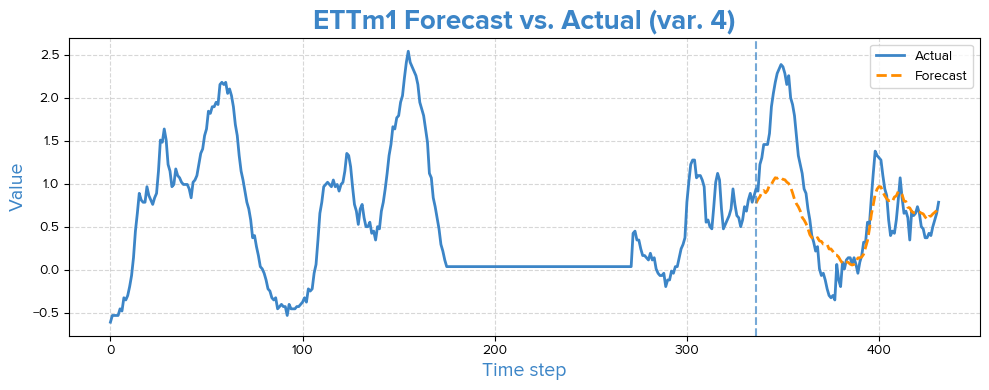

In [42]:
import matplotlib.font_manager as fm

# --- grab one batch from val_loader ---
model.eval()
with torch.no_grad():
    val_iter = iter(val_loader)
    x_batch, y_batch = next(val_iter)      # x: [B, n_vars, L],  y: [B, n_vars, H]

    x_batch = x_batch.to(device)
    y_batch = y_batch.to(device)
    y_pred  = model(x_batch)                       # [B, n_vars, H]

# --- choose the first example in the batch and variable index 0 ---
var_idx = 4
hist = x_batch[0, var_idx, :].cpu().numpy()       # shape (L,)
true = y_batch[0, var_idx, :].cpu().numpy()       # shape (H,)
pred = y_pred[0, var_idx, :].cpu().numpy()        # shape (H,)

# --- stitch history + true future into one series ---
history_length = hist.shape[0]
actual_series  = np.concatenate([hist, true])     # length L+H


# — Font setup (Proxima Nova fallback) —
try:
    font_path = "/content/gdrive/MyDrive/CS4782-Final/proximanova_regular.ttf"
    bold_path = "/content/gdrive/MyDrive/CS4782-Final/proximanova_bold.otf"
    prop = fm.FontProperties(fname=font_path)
    bold = fm.FontProperties(fname=bold_path)
except:
    prop = fm.FontProperties(family="DejaVu Sans")
    bold = fm.FontProperties(family="DejaVu Sans", weight="bold")

# — Plot styling —
color = "#3c85c7"
color2 = "#FF8C00"

plt.figure(figsize=(10, 4))

# plot the full actual series
plt.plot(
    np.arange(len(actual_series)),
    actual_series,
    label="Actual",
    color=color,
    linewidth=2
)

# plot the forecast (with circle markers)
plt.plot(
    np.arange(history_length, history_length + len(pred)),
    pred,
    label="Forecast",
    color=color2,
    linewidth=2,
    linestyle="--"
)

# vertical line at forecast start
plt.axvline(history_length, color=color, linestyle="--", alpha=0.7)

# labels & title
plt.title("ETTm1 Forecast vs. Actual (var. 4)", fontproperties=bold, fontsize=20, color=color)
plt.xlabel("Time step",      fontproperties=prop, fontsize=14, color=color)
plt.ylabel("Value",          fontproperties=prop, fontsize=14, color=color)

# ticks
plt.xticks(fontproperties=prop)
plt.yticks(fontproperties=prop)

# grid
plt.grid(True, linestyle="--", alpha=0.5)

# legend
plt.legend(prop=prop)

plt.tight_layout()
plt.show()

In [ ]:
# save full state
torch.save(model.state_dict(), base_dir + 'patchtst.pth')

In [ ]:
# later, to reload:
model = PatchTST(input_length, patch_len=16, stride=8, forecast_horizon=forecast_horizon)
model.load_state_dict(torch.load(base_dir+'patchtst.pth'))
model.to(device).eval()

In [ ]:
from PatchTST_self_supervised import PatchTSTSelfSupervised, self_supervised_loss
from utils import train_self_supervised, val_self_supervised
model = PatchTSTSelfSupervised(input_length=336, patch_len=16, stride=16)  # non-overlapping
x = torch.randn(32, 8, 336)
reconstructed, original, mask = model(x)
loss = self_supervised_loss(reconstructed, original, mask)

In [ ]:
dataset = SelfSupervisedTimeSeriesDataset(base_dir + "data/ETTh1.csv", input_length)
n_total = len(dataset)
n_train = int(0.8 * n_total)
train_idx = list(range(0, n_train))
val_idx   = list(range(n_train, n_total))

train_ds = Subset(dataset, train_idx)
val_ds   = Subset(dataset, val_idx)

train_loader = DataLoader(
    train_data,
    batch_size=batch_size,
    shuffle=True,
    drop_last=True
)

val_loader = DataLoader(
    val_data,
    batch_size=batch_size,
    shuffle=False
)

In [ ]:

model = PatchTSTSelfSupervised(
    input_length=input_length,
    patch_len=16,
    stride=16,
    d_model=128,
    n_heads=8,
    n_layers=3,
    mask_ratio=0.4
).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3, betas=(0.9, 0.98), eps=1e-9)
print('here')
train_loss_arr, val_loss_arr = train_self_supervised(
    model, train_loader, val_loader, self_supervised_loss = self_supervised_loss,
    optimizer=optimizer, epochs=10,
    device=device
)


here
Starting training...
Epoch 1/10


train:   0%|          | 0/435 [00:00<?, ?it/s]


ValueError: not enough values to unpack (expected 3, got 2)

In [ ]:
loss

tensor(1.3577, grad_fn=<MeanBackward0>)